# **Hyperparameter Tuning for the GA Meal Planner**

In [4]:
import json
import sys
from datetime import datetime, timedelta
from random import Random

from optuna import create_study
from optuna.samplers import TPESampler
from optuna.trial import Trial
from optuna.visualization import (
    plot_optimization_history,
    plot_parallel_coordinate,
    plot_param_importances,
)

sys.path.append("..")

from engines import GAMealPlanner, load_all_ingredients
from models import (
    MealPlanningEnvironment,
    Pantry,
    PantryIngredient,
    UserPreferences,
)

The default user preferences are set for tuning the GA Meal Planner.

In [5]:
preferences = UserPreferences(
    weekly_budget=50,
    calorie_target_per_day=2500,
    protein_target_per_day=80,
    is_vegetarian=False,
    is_vegan=False,
    requires_gluten_free=False,
    requires_lactose_free=False,
)

In [6]:
all_ingredients = load_all_ingredients("../recipe_extraction/supplemented_structured_ingredients.json")

In [7]:
SEED = 1

PANTRY_SIZE = 20

QUANTITY_MIN = 200
QUANTITY_MAX = 2000

COST_MIN = 0.50
COST_MAX = 5.00

EXPIRY_DAYS_MIN = 1
EXPIRY_DAYS_MAX = 14

INGREDIENT_COST_SEED = 1

In [8]:
rng = Random(SEED)

CURRENT_DATE = datetime.now()

sampled_ingredients = rng.sample(all_ingredients, PANTRY_SIZE)

pantry = Pantry()

for ingredient in sampled_ingredients:
    quantity = rng.randint(QUANTITY_MIN, QUANTITY_MAX)
    expiry_days = rng.randint(EXPIRY_DAYS_MIN, EXPIRY_DAYS_MAX)

    pantry_ingredient = PantryIngredient(
        name=ingredient.name,
        nutritional_information=ingredient.nutritional_information,
        estimated_expiration_date=CURRENT_DATE + timedelta(days=expiry_days),
    )
    pantry.add(pantry_ingredient, quantity)

meal_planning_environment = MealPlanningEnvironment(
    recipes=[],
    pantry=pantry,
    preferences=preferences,
)
meal_planning_environment.load_recipes_from_json("../recipe_extraction/supplemented_structured_recipes.json")

pantry.print()

---
Quantity: 1911 g
Ingredient: unsalted kosher-for-Passover pareve (non-dairy) margarine
	Estimated Expiration Date: 2026-05-05
	Nutritional Information:
		Calories: 714.0 kcal
		Carbohydrates: 0.0 g
		Sugar: None g
		Protein: 0.0 g
		Fat: 78.57 g
		Saturated Fat: 10.71 g
		Fiber: None g
		Sodium: 0.0 mg
		Gluten Free: Yes
		Lactose Free: Yes
		Vegetarian: Yes
		Vegan: Yes
---
---
Quantity: 1086 g
Ingredient: white truffles
	Estimated Expiration Date: 2026-05-08
	Nutritional Information:
		Calories: 639.0 kcal
		Carbohydrates: 38.89 g
		Sugar: 38.89 g
		Protein: 5.56 g
		Fat: 52.78 g
		Saturated Fat: 36.11 g
		Fiber: 0.0 g
		Sodium: 83.0 mg
		Gluten Free: Yes
		Lactose Free: Yes
		Vegetarian: Yes
		Vegan: Yes
---
---
Quantity: 1761 g
Ingredient: orange wheel
	Estimated Expiration Date: 2026-05-11
	Nutritional Information:
		Calories: 381.0 kcal
		Carbohydrates: 90.48 g
		Sugar: 90.48 g
		Protein: 4.76 g
		Fat: 0.0 g
		Saturated Fat: None g
		Fiber: None g
		Sodium: 381.0 mg
		Gluten 

In [9]:
all_ingredient_names = []
for recipe in meal_planning_environment.recipes:
    for ingredient_name in recipe.ingredients.keys():
        all_ingredient_names.append(ingredient_name)

all_ingredient_costs = {}
for ingredient_name in sorted(set(all_ingredient_names)):
    all_ingredient_costs[ingredient_name] = rng.random()

meal_planning_environment.ingredient_costs = all_ingredient_costs
meal_planning_environment._check_ingredient_costs()

In [10]:
sampler = TPESampler(seed=SEED)

In [11]:
study = create_study(direction="maximize", study_name="GA Meal Planner Hyperparameter Tuning", sampler=sampler)

[I 2026-04-28 19:55:12,508] A new study created in memory with name: GA Meal Planner Hyperparameter Tuning


In [12]:
NUM_DAYS = 7
NUM_MEALS_PER_DAY = 3
TUNING_SEED = 1

# fixed at 50 to keep tuning time reasonable. Increasing num generations is almost but guaranteed to increase performance, so this is more of a practical choice to keep tuning time manageable
TUNING_NUM_GENERATIONS = 50

In [13]:
def optimise(trial: Trial) -> float:
    """
    Optimisation objective function for the GA Meal Planner

    Tunes only the GA operator hyperparameters (selection, crossover, mutation operators and their settings)

    The generation count is intentionally fixed at a constant low budget so that all trials are comparable and Optuna cannot trivially maximise fitness by simply preferring more generations

    :param trial: an Optuna trial object
    :type trial: optuna.trial.Trial

    :return: the fitness score of the best meal plan generated by the GA Meal Planner with the given hyperparameters
    :rtype: float
    """

    population_size = trial.suggest_int("population_size", 20, 200, step=20)
    num_parents_mating = trial.suggest_int("num_parents_mating", 2, population_size, step=2)
    parent_selection_type = trial.suggest_categorical(
        "parent_selection_type", ["sss", "rws", "sus", "random", "tournament"]
    )
    k_tournament = trial.suggest_int("K_tournament", 2, 10)
    keep_elitism = trial.suggest_int("keep_elitism", 0, 1)
    crossover_type = trial.suggest_categorical("crossover_type", ["single_point", "two_points", "uniform", "scattered"])
    crossover_probability = trial.suggest_float("crossover_probability", 0.5, 1.0, step=0.1)
    mutation_type = trial.suggest_categorical("mutation_type", ["random", "swap", "inversion", "scramble"])
    mutation_probability = trial.suggest_float("mutation_probability", 0.01, 0.5, step=0.01)

    ga_meal_planner = GAMealPlanner(meal_planning_environment)

    _, best_fitness = ga_meal_planner.generate_meal_plan(
        num_days=NUM_DAYS,
        meals_per_day=NUM_MEALS_PER_DAY,
        num_generations=TUNING_NUM_GENERATIONS,
        num_parents_mating=num_parents_mating,
        population_size=population_size,
        parent_selection_type=parent_selection_type,
        K_tournament=k_tournament,
        keep_elitism=keep_elitism,
        crossover_type=crossover_type,
        crossover_probability=crossover_probability,
        mutation_type=mutation_type,
        mutation_probability=mutation_probability,
        generation_print_interval=None,
        seed=TUNING_SEED,
    )

    return best_fitness

In [14]:
NUM_TRIALS = 1000

In [15]:
study.optimize(
    optimise,
    n_trials=NUM_TRIALS,
    show_progress_bar=True,
)

print(f"\nBest trial: #{study.best_trial.number}")
print(f"Best fitness score: {study.best_value:.4f}")

  0%|          | 0/1000 [00:00<?, ?it/s]

[I 2026-04-28 19:55:19,343] Trial 0 finished with value: -12342.445333768654 and parameters: {'population_size': 100, 'num_parents_mating': 74, 'parent_selection_type': 'rws', 'K_tournament': 5, 'keep_elitism': 0, 'crossover_type': 'uniform', 'crossover_probability': 1.0, 'mutation_type': 'swap', 'mutation_probability': 0.08}. Best is trial 0 with value: -12342.445333768654.
[I 2026-04-28 19:55:19,979] Trial 1 finished with value: -85.81199536427059 and parameters: {'population_size': 40, 'num_parents_mating': 34, 'parent_selection_type': 'sss', 'K_tournament': 2, 'keep_elitism': 0, 'crossover_type': 'two_points', 'crossover_probability': 1.0, 'mutation_type': 'swap', 'mutation_probability': 0.42000000000000004}. Best is trial 1 with value: -85.81199536427059.
[I 2026-04-28 19:55:20,388] Trial 2 finished with value: -80.1438411202623 and parameters: {'population_size': 20, 'num_parents_mating': 16, 'parent_selection_type': 'sss', 'K_tournament': 6, 'keep_elitism': 1, 'crossover_type': 

KeyboardInterrupt: 

In [12]:
best_params = study.best_params

print("Best hyperparameters:")
for key, value in best_params.items():
    print(f"\t- {key}: {value}")

Best hyperparameters:
	- population_size: 160
	- num_parents_mating: 46
	- parent_selection_type: sss
	- K_tournament: 10
	- keep_elitism: 1
	- crossover_type: uniform
	- crossover_probability: 0.6
	- mutation_type: scramble
	- mutation_probability: 0.02


In [17]:
FINAL_NUM_GENERATIONS = 500

In [18]:
ga_final = GAMealPlanner(meal_planning_environment)

_, final_fitness = ga_final.generate_meal_plan(
    num_days=NUM_DAYS,
    meals_per_day=NUM_MEALS_PER_DAY,
    num_generations=FINAL_NUM_GENERATIONS,
    num_parents_mating=best_params["num_parents_mating"],
    population_size=best_params["population_size"],
    parent_selection_type=best_params["parent_selection_type"],
    K_tournament=best_params["K_tournament"],
    keep_elitism=best_params["keep_elitism"],
    crossover_type=best_params["crossover_type"],
    crossover_probability=best_params["crossover_probability"],
    mutation_type=best_params["mutation_type"],
    mutation_probability=best_params["mutation_probability"],
    generation_print_interval=50,
    seed=TUNING_SEED,
)

print(f"\nFinal fitness score ({FINAL_NUM_GENERATIONS} generations): {final_fitness:.4f}")
print(f"Tuning fitness score ({TUNING_NUM_GENERATIONS} generations): {study.best_value:.4f}")

Generation 50, Best Fitness: -36.10
Generation 100, Best Fitness: -33.91
Generation 150, Best Fitness: -33.91
Generation 200, Best Fitness: -33.91
Generation 250, Best Fitness: -33.91
Generation 300, Best Fitness: -33.91
Generation 350, Best Fitness: -33.91
Generation 400, Best Fitness: -33.91
Generation 450, Best Fitness: -33.91
Generation 500, Best Fitness: -33.91

Final fitness score (500 generations): -33.9090
Tuning fitness score (50 generations): -36.1019


In [19]:
with open("best_ga_meal_planner_hyperparameters.json", "w") as file:
    json.dump(best_params, file, indent=4)

In [20]:
trials_df = study.trials_dataframe()
trials_df = trials_df.sort_values("value", ascending=False).reset_index(drop=True)
trials_df

,number,value,datetime_start,datetime_complete,duration,params_K_tournament,params_crossover_probability,params_crossover_type,params_keep_elitism,params_mutation_probability,params_mutation_type,params_num_parents_mating,params_parent_selection_type,params_population_size,state
0,974,-36.101878,2026-04-27 21:11:42.475979,2026-04-27 21:11:45.648647,0 days 00:00:03.172668,10,0.6,uniform,1,0.26,scramble,46,sss,160,COMPLETE
1,778,-36.101878,2026-04-27 20:57:04.037937,2026-04-27 20:57:07.152959,0 days 00:00:03.115022,10,0.6,uniform,1,0.28,scramble,46,sss,160,COMPLETE
2,637,-36.101878,2026-04-27 20:49:46.271559,2026-04-27 20:49:49.376297,0 days 00:00:03.104738,10,0.6,uniform,1,0.22,scramble,46,sss,160,COMPLETE
3,632,-36.101878,2026-04-27 20:49:30.432831,2026-04-27 20:49:33.517237,0 days 00:00:03.084406,10,0.6,uniform,1,0.02,scramble,46,sss,160,COMPLETE
4,621,-36.101878,2026-04-27 20:48:51.396825,2026-04-27 20:48:54.494739,0 days 00:00:03.097914,10,0.6,uniform,1,0.02,scramble,46,sss,160,COMPLETE
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
995,4,-20569.534606,2026-04-27 19:59:24.443784,2026-04-27 19:59:28.133742,0 days 00:00:03.689958,5,0.8,uniform,0,0.21,swap,70,sus,200,COMPLETE
996,843,-46393.185066,2026-04-27 21:00:20.471715,2026-04-27 21:00:23.479968,0 days 00:00:03.008253,10,0.6,two_points,0,0.22,scramble,44,rws,160,COMPLETE
997,649,-50579.700173,2026-04-27 20:50:23.938595,2026-04-27 20:50:26.954297,0 days 00:00:03.015702,10,0.6,uniform,0,0.27,scramble,40,sus,160,COMPLETE
998,487,-52323.974008,2026-04-27 20:40:47.223074,2026-04-27 20:40:50.209506,0 days 00:00:02.986432,10,0.6,scattered,0,0.01,inversion,52,sus,160,COMPLETE


In [21]:
plot_optimization_history(study).show()

In [22]:
plot_param_importances(study).show()

In [23]:
plot_parallel_coordinate(study).show()

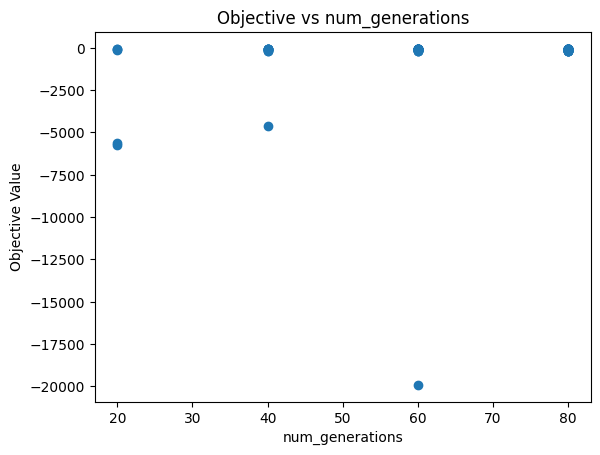

In [22]:
import matplotlib.pyplot as plt

x = []
y = []

for trial in study.trials:
    if trial.value is not None:
        x.append(trial.params["num_generations"])
        y.append(trial.value)

plt.scatter(x, y)
plt.xlabel("num_generations")
plt.ylabel("Objective Value")
plt.title("Objective vs num_generations")
plt.show()